# Chapter 8: Recurrent Neural Networks

Note: had issues with a few packages. Did not run code.

### Simple RNN:

In [ ]:
from functools import cached_property
import numpy as np
import numpy.typing as npt
import pandas as pd

class RNNState:
    """
    Describes a RNN state and computes the history of the states
    based on inputs.
    :param w_h: $W_h$, the weight for $h$
    :param w_i: $W_i$, the weight for $x$
    :param b: $b$, the bias before applying activation
    :param h_init: the initial hidden state
    :param activation: the activation function to be applied.
    """
    def __init__(
    self,
    w_h: npt.ArrayLike,
    w_i: npt.ArrayLike,
    b: npt.ArrayLike,
    h_init: npt.ArrayLike,
    activation: callable = np.tanh,
    ):
        self.w_h = np.array(w_h)
        self.w_i = np.array(w_i)
        self.b = np.array(b)
        self.h_init = np.array(h_init)
        self.activation = activation

    def compute_new_state(
        self, h_current: npt.ArrayLike, z_i: npt.ArrayLike
        ) -> tuple[npt.ArrayLike, npt.ArrayLike]:
        """
        compute_new_state computes a new state
        :param h_current: the current hidden state
        :param z_i: external input

        :return: the new hidden state, and the difference between new and old
        """
        h_new = self.activation(np.dot(self.w_h, h_current) + np.dot(self.w_i, z_i) + self.b)
        h_delta = h_new - h_current
        return h_new, h_delta

    def states(self, z: npt.ArrayLike) -> dict[str : npt.ArrayLike]:
        """
        states calculates the history of RNN states.
        We designed function to be easily readable by
        computing the values step by step.
        It is not efficient.
        :param z: input values for the RNN
        :return: history of the RNN hidden states
        """
        h_t = [self.h_init]
        t_steps = [0]
        h_t_delta = [np.zeros_like(self.h_init)]
        for t, z_i in enumerate(z):
            h_new, h_delta = self.compute_new_state(
            h_current=h_t[-1], z_i=z_i
            )
            h_t.append(h_new)
            h_t_delta.append(h_delta)
            t_steps.append(t + 1)

        total_time_steps = len(t_steps)
        return {
            **{
            "t": np.array(t_steps),
            "h": np.array(h_t),
            "dh": np.array(h_t_delta),
            "z": np.pad(z, (1,0), constant_values=0)
            },
            **{
                k: [v] * total_time_steps
                for k, v in self._metadata.items()
            },
        }

    @cached_property
    def _metadata(self) -> dict:
        return {
            "experiment": (
             f"w_h={np.array2string(self.w_h)}; "
             f"w_i={np.array2string(self.w_i)};"
             f"b={np.array2string(self.b)}; "
             f"h_init={np.array2string(self.h_init)}; "
             f"{self.activation.__name__}"
             ),
             "w_h": np.array2string(self.w_h),
             "w_i": np.array2string(self.w_i),
             "b": np.array2string(self.b),
             "activation": self.activation.__name__,
             "initial_state": np.array2string(self.h_init),
        }

### Forecasting using RNNs

To begin our journey of forecasting using RNNs, we construct a toy problem to show the concepts
of building a forecaster using RNNs. We will generate a sinusoid dataset, train an RNN model, and
benchmark it against a naive forecaster. In this tutorial, you shall grasp most of the basic concepts of
creating a forecaster using PyTorch. We will skip backtesting and hyperparameter tuning in this tutorial.

First of all, we build our dataset using NumPy and pandas. To ensure the model training captures the
oscillations in the data, the sinusoid dataset contains many cycles (see Figure 8.15):

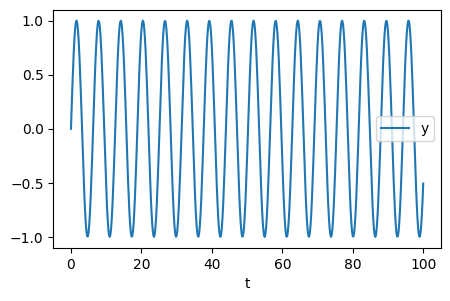

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(
 {
 "t": np.linspace(0, 100, 501),
 "y": np.sin(np.linspace(0, 100, 501))
 }
)
_, ax = plt.subplots(figsize=(5, 3.09))
df.plot(x="t", y="y", ax=ax);

Next, we create an RNN model using PyTorch. We will use the torch.nn.RNN model provided by
PyTorch. When building our models, we always assume that the tensors for time series have the
dimension (batch size, sequence length, number of variables).
First of all, we create a dataclass to hold all the model parameters:

In [ ]:
import dataclasses
import torch
from torch import nn

@dataclasses.dataclass
class TSRNNParams:
    """A dataclass to be served as our parameters
    for the RNN model.
    :param hidden_size: number of dimensions
    in the hidden state
    :param input_size: input dim
    :param num_layers: number of units stacked
    """
    input_size: int
    hidden_size: int
    num_layers: int = 1

With the model parameters ready, we can create an RNN model using PyTorch, which accepts the
model parameters as well as the forecast horizon when instantiated. Note that a PyTorch module
requires us to implement the forward method:

In [ ]:
class TSRNN(nn.Module):
    """
    RNN for univaraite time series modeling.
    :param history_length: the length of the input history.
    :param horizon: the number of steps to be forecasted.
    :param rnn_params: the parameters for the RNN network.
    """
    def __init__(
    self, history_length: int,
     horizon: int,
     rnn_params: TSRNNParams
    ):
        super().__init__()

        self.rnn_params = rnn_params
        self.history_length = history_length
        self.horizon = horizon

        self.regulate_input = nn.Linear(
        self.history_length,
        self.rnn_params.input_size
        )

        self.rnn = nn.RNN(
        input_size=self.rnn_params.input_size,
        hidden_size=self.rnn_params.hidden_size,
        num_layers=self.rnn_params.num_layers,
        batch_first=True,)

        self.regulate_output = nn.Linear(
        self.rnn_params.hidden_size,
        self.horizon
        )

    @property
    def rnn_config(self):
        return dataclasses.asdict(self.rnn_params)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.regulate_input(x)
        x, _ = self.rnn(x)
        return self.regulate_output(x)

We define our forecasting problem to take in a history length of 100 and a forecast horizon of 1 for
simplicity:

In [ ]:
history_length_1_step = 100
horizon_1_step = 1

To be able to feed the data into our model, we build a class (DataFrameDataset) that converts the pandas DataFrame into a dataset for PyTorch. Since we are focusing on the actual model in this chapter,
we have hidden it in a Python package (ts_bolt), and you need only to focus on the model creation
and training.

To make the lightning training code simpler, we will build a LightningDataModule (DataFrameDataModule)
and a LightningModule (RNNForecaster):
1. First of all, we create the forecaster using Lightning by asking it to accept the TSRNN RNN
model we created in the previous step. We implement training_step, validation_step, and
predict_step in the LightningModule, as well as configure_optimizers to configure our SGD
optimizer. When we are training, the trainer will pick up the training_step method. Similarly,
the training will pick up the validation_step when we are performing validations. We have
removed the docstrings in the class for easier readability in the printed version of the book;
however, it is highly recommended to write docstrings when you write your own code:

In [ ]:
import lightning as L

class RNNForecaster(L.LightningModule):
    """Forecaster based on RNN
    :param rnn: RNN model that takes time
    series input and predicts time series
    of the specified horizon.
    """

    def __init__(self, rnn: nn.Module):
        super().__init__()
        self.rnn = rnn

    def configure_optimizers(self) -> torch.optim.Optimizer:
        optimizer = torch.optim.SGD(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(
    self,
    batch: tuple[torch.Tensor],
    batch_idx: int
    ) -> torch.Tensor:
        x, y = batch
        x = x.squeeze().type(self.dtype)
        y = y.squeeze(-1).type(self.dtype)
        y_hat = self.rnn(x)
        loss = nn.functional.l1_loss(y_hat, y)
        self.log_dict({"train_loss": loss}, prog_bar=True)
        return loss

    def validation_step(
    self,
    batch: tuple[torch.Tensor],
    batch_idx: int
    ) -> torch.Tensor:
        x, y = batch
        x = x.squeeze().type(self.dtype)
        y = y.squeeze(-1).type(self.dtype)
        y_hat = self.rnn(x)
        loss = nn.functional.l1_loss(y_hat, y)
        self.log_dict({"val_loss": loss}, prog_bar=True)
        return loss

    def predict_step(
    self,
    batch: tuple[torch.Tensor],
    batch_idx: int
    ) -> tuple[torch.Tensor]:
        x, y = batch
        x = x.squeeze().type(self.dtype)
        y = y.squeeze(-1).type(self.dtype)
        y_hat = self.rnn(x)
        return x, y_hat

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor]:
        x = x.squeeze().type(self.dtype)
        return x, self.rnn(x)

2. The data module is built based on the DataFrame. We take 100 steps as input and the next step
as the value to be predicted. We slide forward with step size 1 to create our dataset:

In [ ]:
from ts_bolt.datamodules.pandas import DataFrameDataModule

pdm_1_step = DataFrameDataModule(
 history_length=history_length_1_step,
 horizon=horizon_1_step,
 dataframe=df[["y"]],
)

With all the ingredients prepared, we instantiate our model:

In [ ]:
from torchinfo import summary

ts_rnn_params_1_step = TSRNNParams(
 input_size=100,
 hidden_size=64,
 num_layers=1
)

ts_rnn_1_step = TSRNN(
 history_length=history_length_1_step,
 horizon=horizon_1_step,
 rnn_params=ts_rnn_params_1_step,
)

summary(ts_rnn_1_step)

We can also observe that our model is quite small as it has a small number of parameters. The
whole training will be fast even on our personal laptops.

3. We create the actual encapsulated forecaster using the RNN model we instantiated in the
previous step:

In [ ]:
rnn_forecaster_1_step = RNNForecaster(rnn=ts_rnn_1_step)

4. PyTorch Lightning provides an easy-to-use trainer for our model. We create the trainer and
fit our model:

In [ ]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

logger_1_step = L.pytorch.loggers.TensorBoardLogger(
 save_dir="lightning_logs",
 name="rnn_ts_1_step"
)

trainer_1_step = L.Trainer(
 precision="64",
 max_epochs=100,
 min_epochs=5,
 callbacks=[
EarlyStopping(
 monitor="val_loss",
 mode="min",
 min_delta=1e-7,
 patience=3
 )
 ],
 logger=logger_1_step,
)

trainer_1_step.fit(
 model=rnn_forecaster_1_step,
 datamodule=pdm_1_step
)

5. During fitting, the trainer takes the training data loader and validation data loader prepared
in the pdm_1_step data module. Once the model is trained, we can forecast using the predict
method, which takes the predict data loader and performs a forward pass:

In [ ]:
predictions_1_step = trainer_1_step.predict(model=rnn_forecaster_1_step, datamodule=pdm_1_step)

6.  To build up intuitions of our forecasts, we also produce forecasts using the last observation,
that is, forecast
$$
x[t+1] \equiv x[t]
$$


In [ ]:
from ts_bolt.naive_forecasters.last_observation import LastObservationForecaster

trainer_naive_1_step = L.Trainer(precision="64")

lobs_forecaster_1_step = LastObservationForecaster(horizon=horizon_1_step)

lobs_1_step_predictions = trainer_naive_1_step.predict(model=lobs_forecaster_1_step, datamodule=pdm_1_step)

7. To evaluate our model performance, we compare the RNN model output and the naive last
observation forecaster in a plot. We observe that the RNN model seems to be better than the
naive model:

In [ ]:
from ts_bolt.evaluation.evaluator import Evaluator

evaluator_1_step = Evaluator(step=0)
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(
 evaluator_1_step.y_true(
 dataloader=pdm_1_step.predict_dataloader()
 ),
 "g-",
 label="truth",
)

ax.plot(evaluator_1_step.y(predictions_1_step), "r--", label="predictions")
ax.plot(evaluator_1_step.y(lobs_1_step_predictions), "b-.", label="naive predictions")
plt.legend()

8.  To quantify the model comparison, we compute the metrics for the two models. The RNN
model performs better in terms of every metric we computed:

In [ ]:
pd.merge(
 evaluator_1_step.metrics(
 predictions_1_step, pdm_1_step.predict_dataloader()),
 evaluator_1_step.metrics(
 lobs_1_step_predictions, pdm_1_step.predict_dataloader()),
 how="inner",
 left_index=True, right_index=True,
 suffixes=["_rnn", "_last_obs"]
)

While we have successfully built an RNN model, we had to create a series of utilities, which takes a
lot of time. Note that we have not yet performed any backtesting in our RNN example, nor have we
tuned the hyperparameters of the model. In a real-world forecasting project, both backtesting and
hyperparameter tuning are core to the workflow.

In reality, we usually don’t write our barebones model from scratch but use packages. Most deep
learning-based forecasting packages provide RNN models. For example, Darts provides RNNModel,
which packages together training, inference, model saving, and even simple hyperparameter tuning.
Similarly, Nixtla also provides the RNN model as well as a toolkit to use a pandas DataFrame as input
data, which simplifies our workflow a lot. Both Darts and Nixtla provide easy-to-use evaluation utilities.